In [1]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

_USETEX = shutil.which("latex") is not None
rc("text", usetex=_USETEX)
rc("font", **{"family": "sans-serif", "sans-serif": ["Helvetica"],
              "weight": "bold", "size": 16})
print("usetex =", _USETEX)

usetex = True


# Z4 PRS trials — μ, H0/μ, friction strength, staged-after-formation

Analysis of the post-diagnostic trial runs (`src/models/parameter-files/scan_z4_prs_trials/`,
runner `buildZ4_stable/runner_trials.sh`). All β₄=0.1, N=256, dx=0.70 (same box). Loads the 9
trial runs plus the relevant diagnostic references from `scan_z4_prs_diag/` (v0std = standard
EOM baseline, v3both = PRS-from-t₀ frozen reference, v4stag = mid-transition staged switch).

**Questions, and the runs that answer them:**
1. **Is μ degenerate?** `friction` (μ=0.01) vs `friction_mu0p1` (μ=0.1), else identical in program
   units → should overlay vs η *and* vs a. (Old-param μ benchmarks don't bind the current β₄ code.)
2. **Which way does the breaking-`a` move with Hubble drag?** `std_H0p5` / v0std / `std_H0x3`
   (H0/μ = 0.5, 1, 3). Resolution cares about `a_break`; η_break is the other clock.
3. **Does PRS-from-t₀ break if we change the drag?** `prs_t0_H0p5` / v3both / `prs_t0_H0x3`.
4. **Friction strength to reach scaling ~10–20 η faster:** Γ = 0 (v0std) / 0.5 / 1.0 / 2.0.
5. **Does switching PRS on *after* full formation avoid the v4stag drain?** `stagedPRS_postform`
   (switch a≥60) vs v4stag (a≥50) vs v0std.

> Runs still in progress show as MISSING and are skipped; re-run cells as data lands.

In [2]:
BASE_TRIALS = "/mt/user-batch/dpasari/scan_z4_prs_trials/"
BASE_DIAG   = "/mt/user-batch/dpasari/scan_z4_prs_diag/"

MU0      = 0.01           # reference mu
BETA4    = 0.1
N_LAT    = 256
DX       = 179.2 / N_LAT  # 0.70 (same box for every trial)
DELTA_OPP = 1.40                       # type-2 (diagonal) width, program units
DELTA_ADJ = 2.380                      # type-1 (adjacent) width at beta4=0.1
DELTA_MIN = min(DELTA_ADJ, DELTA_OPP)  # 1.40 -> sets resolution
V0       = MU0 * MU0 / 4.0             # +V at phi=0 (=2.5e-5); broken vacuum gives -V0

# registry: key -> attributes.  kind in {std, friction, prs_t0, staged}
RUNS = {
  # ---- diagnostic references ----
  "v0std":     dict(base=BASE_DIAG,   sub="results_DWZ4_b40p1_v0std",   kind="std",      h0r=1.0, gamma=0.0, mu=0.01, switch=None, ref=True),
  "v3both":    dict(base=BASE_DIAG,   sub="results_DWZ4_b40p1_v3both",  kind="prs_t0",   h0r=1.0, gamma=0.0, mu=0.01, switch=0,    ref=True),
  "v4stag":    dict(base=BASE_DIAG,   sub="results_DWZ4_b40p1_v4stag",  kind="staged",   h0r=1.0, gamma=0.0, mu=0.01, switch=50,   ref=True),
  # ---- mu-degeneracy test ----
  "fric_mu01": dict(base=BASE_TRIALS, sub="results_DWZ4_friction_b40p1",       kind="friction", h0r=1.0, gamma=1.0, mu=0.01, switch=None),
  "fric_mu1":  dict(base=BASE_TRIALS, sub="results_DWZ4_friction_mu0p1_b40p1", kind="friction", h0r=1.0, gamma=1.0, mu=0.10, switch=None),
  # ---- friction strength bracket ----
  "fric_g05":  dict(base=BASE_TRIALS, sub="results_DWZ4_friction_g0p5_b40p1",  kind="friction", h0r=1.0, gamma=0.5, mu=0.01, switch=None),
  "fric_g2":   dict(base=BASE_TRIALS, sub="results_DWZ4_friction_g2_b40p1",    kind="friction", h0r=1.0, gamma=2.0, mu=0.01, switch=None),
  # ---- H0/mu lever: standard EOM ----
  "std_h05":   dict(base=BASE_TRIALS, sub="results_DWZ4_std_H0p5_b40p1",  kind="std", h0r=0.5, gamma=0.0, mu=0.01, switch=None),
  "std_h3":    dict(base=BASE_TRIALS, sub="results_DWZ4_std_H0x3_b40p1",  kind="std", h0r=3.0, gamma=0.0, mu=0.01, switch=None),
  # ---- H0/mu lever: PRS from t0 ----
  "prst0_h05": dict(base=BASE_TRIALS, sub="results_DWZ4_prs_t0_H0p5_b40p1", kind="prs_t0", h0r=0.5, gamma=0.0, mu=0.01, switch=0),
  "prst0_h3":  dict(base=BASE_TRIALS, sub="results_DWZ4_prs_t0_H0x3_b40p1", kind="prs_t0", h0r=3.0, gamma=0.0, mu=0.01, switch=0),
  # ---- staged after formation ----
  "staged60":  dict(base=BASE_TRIALS, sub="results_DWZ4_stagedPRS_postform_b40p1", kind="staged", h0r=1.0, gamma=0.0, mu=0.01, switch=60),
}

def path(key):
    r = RUNS[key]
    return os.path.join(r["base"], r["sub"])

# colour maps used across plots
H0_COLOR    = {0.5: "#1f77b4", 1.0: "#000000", 3.0: "#d62728"}
GAMMA_COLOR = {0.0: "#000000", 0.5: "#1f77b4", 1.0: "#2ca02c", 2.0: "#d62728"}
print(f"DX={DX:.3f}  DELTA_MIN={DELTA_MIN}  V0=+{V0:.2e}")
print(f"{len(RUNS)} runs registered.")

DX=0.700  DELTA_MIN=1.4  V0=+2.50e-05
12 runs registered.


## Loaders

In [3]:
def load_energies(p):
    fp = os.path.join(p, "average_energies.txt")
    try: d = np.loadtxt(fp)
    except (FileNotFoundError, OSError): return None
    if d.ndim == 1: d = d[None, :]
    if d.shape[1] < 11: return None
    return {"eta": d[:,0], "Ek_1": d[:,1], "Ek_2": d[:,2], "Eg_1": d[:,3], "Eg_2": d[:,4],
            "Ev_1": d[:,5], "Ev_2": d[:,6], "Ev_3": d[:,7], "E_tot": d[:,8],
            "scal1": d[:,9], "scal2": d[:,10]}

def load_scalar(p, idx):
    fp = os.path.join(p, f"average_scalar_{idx}.txt")
    try: d = np.loadtxt(fp)
    except (FileNotFoundError, OSError): return None
    if d.ndim == 1: d = d[None, :]
    return {"eta": d[:,0], "phi": d[:,1], "phi_prime": d[:,2], "rms_phi": d[:,5], "rms_phi_p": d[:,6]}

def load_scale_factor(p):
    fp = os.path.join(p, "average_scale_factor.txt")
    try: d = np.loadtxt(fp)
    except (FileNotFoundError, OSError): return None
    if d.ndim == 1: d = d[None, :]
    return {"eta": d[:,0], "a": d[:,1], "aprime": d[:,2], "H": d[:,3]}

def load_lside(p):
    try:
        with open(os.path.join(p, "DWZ4.infos")) as f:
            for line in f:
                q = line.split()
                if len(q) >= 2 and q[0] == "lSide": return float(q[1])
    except (FileNotFoundError, OSError): return None
    return None

def break_point(en):
    """(eta_break, idx) where Ev_1 first goes negative; (None,None) if never."""
    if en is None: return None, None
    neg = np.where(en["Ev_1"] < 0)[0]
    return (en["eta"][neg[0]], neg[0]) if len(neg) else (None, None)

def area(en, sf, key):
    """A = scal/(2 a H), length-aligned."""
    n = min(len(en["eta"]), len(sf["a"]))
    with np.errstate(divide="ignore", invalid="ignore"):
        A = en[key][:n] / (2.0 * sf["a"][:n] * sf["H"][:n])
    return en["eta"][:n], sf["a"][:n], A

def plateau_onset(eta, A, tol=0.12, tail_frac=0.25):
    """eta at the start of the final contiguous stretch within tol of the tail median (~scaling)."""
    A = np.asarray(A, float); eta = np.asarray(eta, float)
    m = np.isfinite(A)
    if m.sum() < 10: return None
    A, eta = A[m], eta[m]; n = len(A)
    Af = np.median(A[int((1-tail_frac)*n):])
    if not np.isfinite(Af) or Af == 0: return None
    within = np.abs(A - Af)/abs(Af) < tol
    idx = n
    for i in range(n-1, -1, -1):
        if within[i]: idx = i
        else: break
    return eta[idx] if idx < n else None

## Load all runs

In [4]:
for k, r in RUNS.items():
    p = path(k)
    r["energies"] = load_energies(p)
    r["scale_factor"] = load_scale_factor(p)
    r["scalar_0"] = load_scalar(p, 0)
    lside = load_lside(p); r["lside"] = lside; r["dx"] = (lside/N_LAT) if lside else DX

print(f"{'key':10s} {'kind':8s} {'H0/mu':>5s} {'gamma':>5s} {'mu':>5s} {'switch':>6s} "
      f"{'a_break':>7s} {'eta_brk':>7s} {'rms_end':>7s} {'Ev1_end':>10s}  status")
print("-"*104)
for k, r in RUNS.items():
    en, sf, s0 = r["energies"], r["scale_factor"], r["scalar_0"]
    ok = en is not None and sf is not None and s0 is not None
    eb, ib = break_point(en)
    ab = sf["a"][ib] if (ok and ib is not None) else None
    rms_end = s0["rms_phi"][-1] if s0 else float("nan")
    ev1 = en["Ev_1"][-1] if en else float("nan")
    sw = "t0" if r["switch"] == 0 else (str(r["switch"]) if r["switch"] else "--")
    print(f"{k:10s} {r['kind']:8s} {r['h0r']:5.1f} {r['gamma']:5.1f} {r['mu']:5.2f} {sw:>6s} "
          f"{(f'{ab:.1f}' if ab else '--'):>7s} {(f'{eb:.1f}' if eb else '--'):>7s} "
          f"{rms_end:7.3f} {ev1:10.2e}  {'OK' if ok else 'MISSING'}")

key        kind     H0/mu gamma    mu switch a_break eta_brk rms_end    Ev1_end  status
--------------------------------------------------------------------------------------------------------
v0std      std        1.0   0.0  0.01     --    53.7    52.7   0.690  -2.20e-05  OK
v3both     prs_t0     1.0   0.0  0.01     t0      --      --   0.000   2.50e-05  OK
v4stag     staged     1.0   0.0  0.01     50      --      --   0.297   1.62e-05  OK
fric_mu01  friction   1.0   1.0  0.01     --    71.2    70.2   0.641  -1.89e-05  OK
fric_mu1   friction   1.0   1.0  0.10     --    15.4    14.4   0.707  -2.47e-03  OK
fric_g05   friction   1.0   0.5  0.01     --    63.0    62.0   0.667  -2.21e-05  OK
fric_g2    friction   1.0   2.0  0.01     --    75.7    74.7   0.645  -1.71e-05  OK
std_h05    std        0.5   0.0  0.01     --    38.0    73.9   0.719  -2.26e-05  OK
std_h3     std        3.0   0.0  0.01     --    92.2    30.4   0.696  -2.29e-05  OK
prst0_h05  prs_t0     0.5   0.0  0.01     t0      -

## Plot helper

In [5]:
def paper_ax(ax, xlabel=r"$\eta$", ylabel="", title=""):
    ax.set_xlabel(xlabel, fontsize=22)
    if ylabel: ax.set_ylabel(ylabel, fontsize=22)
    if title:  ax.set_title(title, fontsize=18)
    ax.xaxis.set_ticks_position("both"); ax.yaxis.set_ticks_position("both")
    ax.tick_params(axis="both", which="both", direction="in", labelsize=15, pad=6)
    ax.tick_params(which="major", length=8); ax.tick_params(which="minor", length=4)
    ax.minorticks_on(); ax.grid(True, ls="--", lw=0.4, alpha=0.6)

def have(*keys):
    return [k for k in keys if RUNS[k]["energies"] is not None and RUNS[k]["scale_factor"] is not None]

## Q1 · μ is NOT degenerate — it sets the initial fluctuation seed

`friction` (μ=0.01) vs `friction_mu0p1` (μ=0.1), identical in every program-unit quantity
**except** μ. The background `a(η)` and the EOM/potential *are* μ-independent (H(0)=1, same `a(η)`),
but the **initial fluctuation seed scales with μ**: `kCutOff=3` is in program units, so the physical
UV cutoff is `3·ω⋆ = 3μ` and the vacuum-fluctuation amplitude tracks it. With the vev fixed at
`v=1`, the seed/vev ratio ∝ μ — a bigger seed needs less amplification to reach the vacuum, so
**larger μ breaks earlier in both `a` and η, i.e. at smaller `a` ⇒ better resolved.** The printout
shows `rms(η=0) ∝ μ` and the formation-`a` / pts-per-wall for each.

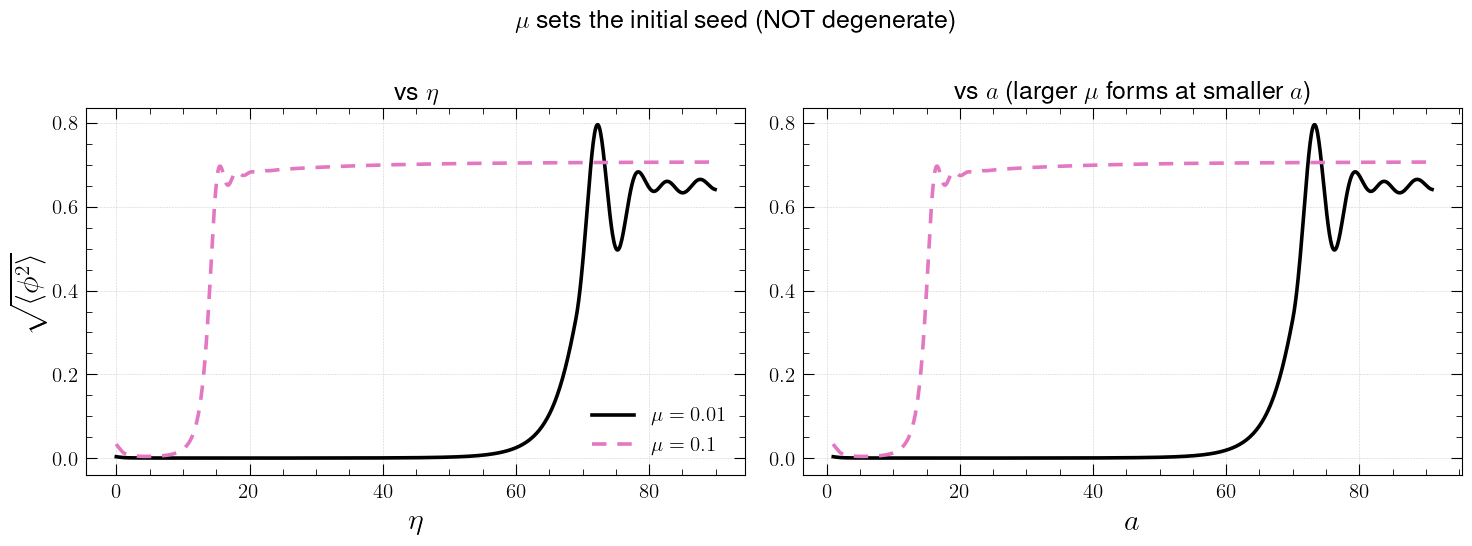

    mu  rms(eta=0)  rms>0.1 @ a  pts/wall@form
  0.01   3.375e-03         65.9          0.030
  0.10   3.376e-02         13.3          0.150
=> rms(eta=0) proportional to mu: mu is an IC-seed knob, not degenerate.
   bigger seed -> breaks at smaller a -> better resolved (good for staging).


In [6]:
ks = have("fric_mu01", "fric_mu1")
if len(ks) < 2:
    print("need both friction runs (waiting on:", [k for k in ("fric_mu01","fric_mu1") if k not in ks], ")")
else:
    fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
    cmap = {"fric_mu01": "#000000", "fric_mu1": "#e377c2"}
    lsd  = {"fric_mu01": "-", "fric_mu1": (0,(4,3))}
    for k in ks:
        r = RUNS[k]; s0 = r["scalar_0"]; sf = r["scale_factor"]
        ax[0].plot(s0["eta"], s0["rms_phi"], color=cmap[k], ls=lsd[k], lw=2.6, label=rf"$\mu={r['mu']}$")
        n = min(len(s0["eta"]), len(sf["a"]))
        ax[1].plot(sf["a"][:n], s0["rms_phi"][:n], color=cmap[k], ls=lsd[k], lw=2.6)
    paper_ax(ax[0], ylabel=r"$\sqrt{\langle\phi^2\rangle}$", title=r"vs $\eta$")
    paper_ax(ax[1], xlabel=r"$a$", title=r"vs $a$ (larger $\mu$ forms at smaller $a$)")
    ax[0].legend(fontsize=15, frameon=False)
    fig.suptitle(r"$\mu$ sets the initial seed (NOT degenerate)", fontsize=18, y=1.0)
    plt.tight_layout(); plt.savefig("Z4_prs_trials_mu_test.pdf", bbox_inches="tight"); plt.show()

    # The smoking gun: rms(eta=0) ~ mu, so larger mu = bigger seed = earlier (smaller-a) breaking.
    print(f"{'mu':>6s} {'rms(eta=0)':>11s} {'rms>0.1 @ a':>12s} {'pts/wall@form':>14s}")
    for k in ["fric_mu01", "fric_mu1"]:
        r = RUNS[k]; s0 = r["scalar_0"]; sf = r["scale_factor"]
        seed = s0["rms_phi"][0]
        hit = np.where(s0["rms_phi"] > 0.1)[0]
        af = sf["a"][hit[0]] if len(hit) else None
        pw = (DELTA_MIN/(af*r["dx"])) if af else float("nan")
        print(f"{r['mu']:6.2f} {seed:11.3e} {(f'{af:.1f}' if af else '--'):>12s} {pw:14.3f}")
    print("=> rms(eta=0) proportional to mu: mu is an IC-seed knob, not degenerate.")
    print("   bigger seed -> breaks at smaller a -> better resolved (good for staging).")

## Q2 · Which way does the breaking-`a` move with Hubble drag?

`std_H0p5` / `v0std` / `std_H0x3` = H0/μ ∈ {0.5, 1, 3}, standard EOM. Resolution depends on
`a_break` (smaller = better resolved); η_break is the other clock. The table tests the
defect-formation guess `a_break ∝ √(H0/μ)`.

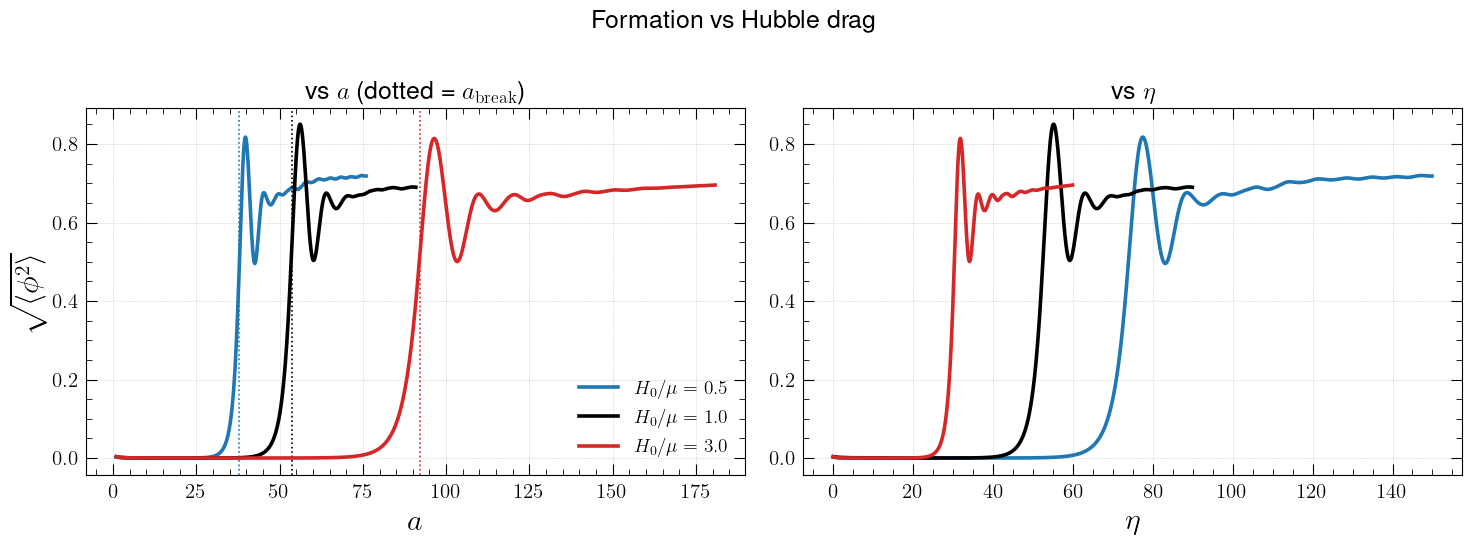

 H0/mu  a_break eta_break  a_break/sqrt(H0/mu)  pts/wall@break
   0.5     38.0      73.9                 53.7          0.0527
   1.0     53.7      52.7                 53.7          0.0372
   3.0     92.2      30.4                 53.2          0.0217
a_break rising with H0/mu => more drag is WORSE for resolution; falling => better.


In [7]:
ks = have("std_h05", "v0std", "std_h3")
if not ks:
    print("waiting on std runs:", [k for k in ("std_h05","v0std","std_h3") if k not in ks])
else:
    fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
    for k in ["std_h05", "v0std", "std_h3"]:
        if k not in ks: continue
        r = RUNS[k]; s0 = r["scalar_0"]; sf = r["scale_factor"]; c = H0_COLOR[r["h0r"]]
        n = min(len(s0["eta"]), len(sf["a"]))
        ax[0].plot(sf["a"][:n], s0["rms_phi"][:n], color=c, lw=2.6, label=rf"$H_0/\mu={r['h0r']}$")
        ax[1].plot(s0["eta"], s0["rms_phi"], color=c, lw=2.6)
        eb, ib = break_point(r["energies"])
        if ib is not None: ax[0].axvline(sf["a"][ib], color=c, ls=":", lw=1.2)
    paper_ax(ax[0], xlabel=r"$a$", ylabel=r"$\sqrt{\langle\phi^2\rangle}$", title=r"vs $a$ (dotted = $a_{\rm break}$)")
    paper_ax(ax[1], title=r"vs $\eta$")
    ax[0].legend(fontsize=14, frameon=False)
    fig.suptitle(r"Formation vs Hubble drag", fontsize=18, y=1.0)
    plt.tight_layout(); plt.savefig("Z4_prs_trials_H0mu_direction.pdf", bbox_inches="tight"); plt.show()

    print(f"{'H0/mu':>6s} {'a_break':>8s} {'eta_break':>9s} {'a_break/sqrt(H0/mu)':>20s} {'pts/wall@break':>15s}")
    for k in ["std_h05", "v0std", "std_h3"]:
        if k not in ks: continue
        r = RUNS[k]; eb, ib = break_point(r["energies"])
        if ib is None:
            print(f"{r['h0r']:6.1f} {'no break':>8s}"); continue
        ab = r["scale_factor"]["a"][ib]
        print(f"{r['h0r']:6.1f} {ab:8.1f} {eb:9.1f} {ab/np.sqrt(r['h0r']):20.1f} {DELTA_MIN/(ab*r['dx']):15.4f}")
    print("a_break rising with H0/mu => more drag is WORSE for resolution; falling => better.")

## Q3 · Does PRS-from-t₀ break if we change the drag?

`prs_t0_H0p5` / `v3both` (H0/μ=1) / `prs_t0_H0x3`. v3both stayed frozen at φ=0; does lowering the
drag (less over-damping) let the frozen-μ² tachyon break? Standard `v0std` shown dashed for scale.

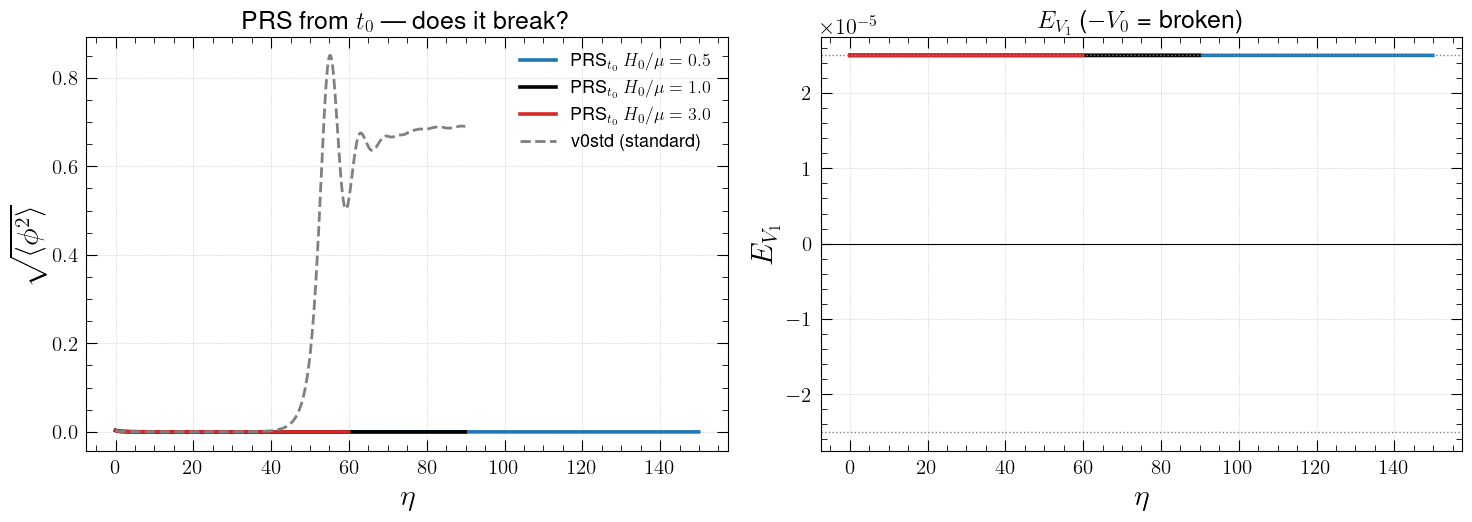

In [8]:
ks = have("prst0_h05", "v3both", "prst0_h3")
if not ks:
    print("waiting on prs_t0 runs:", [k for k in ("prst0_h05","v3both","prst0_h3") if k not in ks])
else:
    fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
    for k in ["prst0_h05", "v3both", "prst0_h3"]:
        if k not in ks: continue
        r = RUNS[k]; s0 = r["scalar_0"]; en = r["energies"]; c = H0_COLOR[r["h0r"]]
        ax[0].plot(s0["eta"], s0["rms_phi"], color=c, lw=2.6, label=rf"PRS$_{{t_0}}$ $H_0/\mu={r['h0r']}$")
        ax[1].plot(en["eta"], en["Ev_1"], color=c, lw=2.6)
    if "v0std" in have("v0std"):
        s0 = RUNS["v0std"]["scalar_0"]
        ax[0].plot(s0["eta"], s0["rms_phi"], color="grey", ls="--", lw=2.0, label="v0std (standard)")
    ax[1].axhline(+V0, color="grey", ls=":", lw=1); ax[1].axhline(-V0, color="grey", ls=":", lw=1)
    ax[1].axhline(0, color="k", lw=0.8)
    paper_ax(ax[0], ylabel=r"$\sqrt{\langle\phi^2\rangle}$", title="PRS from $t_0$ — does it break?")
    paper_ax(ax[1], ylabel=r"$E_{V_1}$", title=r"$E_{V_1}$ ($-V_0$ = broken)")
    ax[0].legend(fontsize=13, frameon=False)
    plt.tight_layout(); plt.savefig("Z4_prs_trials_prst0_drag.pdf", bbox_inches="tight"); plt.show()

## Q4 · Friction strength — does Γ reach scaling ~10–20 η faster?

Γ = 0 (v0std) / 0.5 / 1.0 / 2.0, friction off at a=70 (dotted). Scaling ≈ the wall-area 𝒜
plateau; the printout estimates each plateau-onset η and the speed-up vs Γ=0.

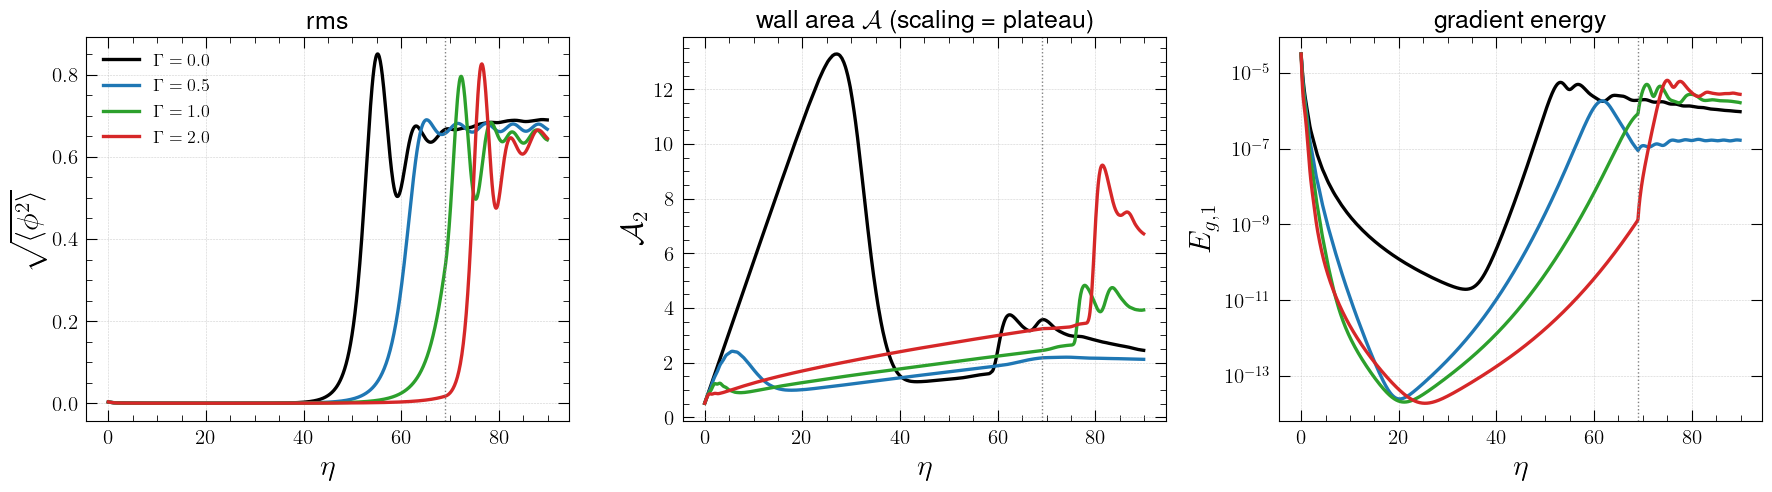

plateau-onset eta of A_2 (scaling reached):
  Gamma=0.0:  onset eta = None   
  Gamma=0.5:  onset eta = 60.9   
  Gamma=1.0:  onset eta = 85.2   
  Gamma=2.0:  onset eta = None   


In [12]:
order = ["v0std", "fric_g05", "fric_mu01", "fric_g2"]   # gamma 0, 0.5, 1.0, 2.0
ks = have(*order)
if not ks:
    print("waiting on friction runs:", [k for k in order if k not in ks])
else:
    fig, ax = plt.subplots(1, 3, figsize=(18, 5.2))
    onset = {}
    for k in order:
        if k not in ks: continue
        r = RUNS[k]; s0 = r["scalar_0"]; en = r["energies"]; sf = r["scale_factor"]
        c = GAMMA_COLOR[r["gamma"]]; lab = rf"$\Gamma={r['gamma']}$"
        ax[0].plot(s0["eta"], s0["rms_phi"], color=c, lw=2.4, label=lab)
        eta, a, A = area(en, sf, "scal1")
        ax[1].plot(eta, A, color=c, lw=2.4)
        onset[r["gamma"]] = plateau_onset(eta, A)
        ax[2].plot(en["eta"], np.abs(en["Eg_1"])+1e-30, color=c, lw=2.4)
    # mark friction switch-off a=70 -> eta on the H0/mu=1 background (~a=1+eta)
    for axx in ax: axx.axvline(69.0, color="grey", ls=":", lw=1.0)
    paper_ax(ax[0], ylabel=r"$\sqrt{\langle\phi^2\rangle}$", title="rms")
    paper_ax(ax[1], ylabel=r"$\mathcal{A}_2$", title=r"wall area $\mathcal{A}$ (scaling = plateau)")
    paper_ax(ax[2], ylabel=r"$E_{g,1}$", title="gradient energy"); ax[2].set_yscale("log")
    ax[0].legend(fontsize=13, frameon=False)
    plt.tight_layout(); plt.savefig("Z4_prs_trials_friction.pdf", bbox_inches="tight"); plt.show()

    print("plateau-onset eta of A_2 (scaling reached):")
    base = onset.get(0.0)
    for g in sorted(onset):
        o = onset[g]
        spd = (f"{base-o:+.1f} eta vs Gamma=0" if (o is not None and base is not None) else "")
        print(f"  Gamma={g}:  onset eta = {o if o is None else round(o,1)}   {spd}")

## Q5 · Staged PRS *after* full formation — does it avoid the drain?

`stagedPRS_postform` (switch a≥60) vs `v4stag` (a≥50, mid-transition) vs `v0std` (no PRS).
Dotted verticals mark each switch. If post-formation switching holds (no drain), rms stays up
and 𝒜 plateaus; if it still drains/freezes a sub-grid wall, rms falls and Eg collapses.

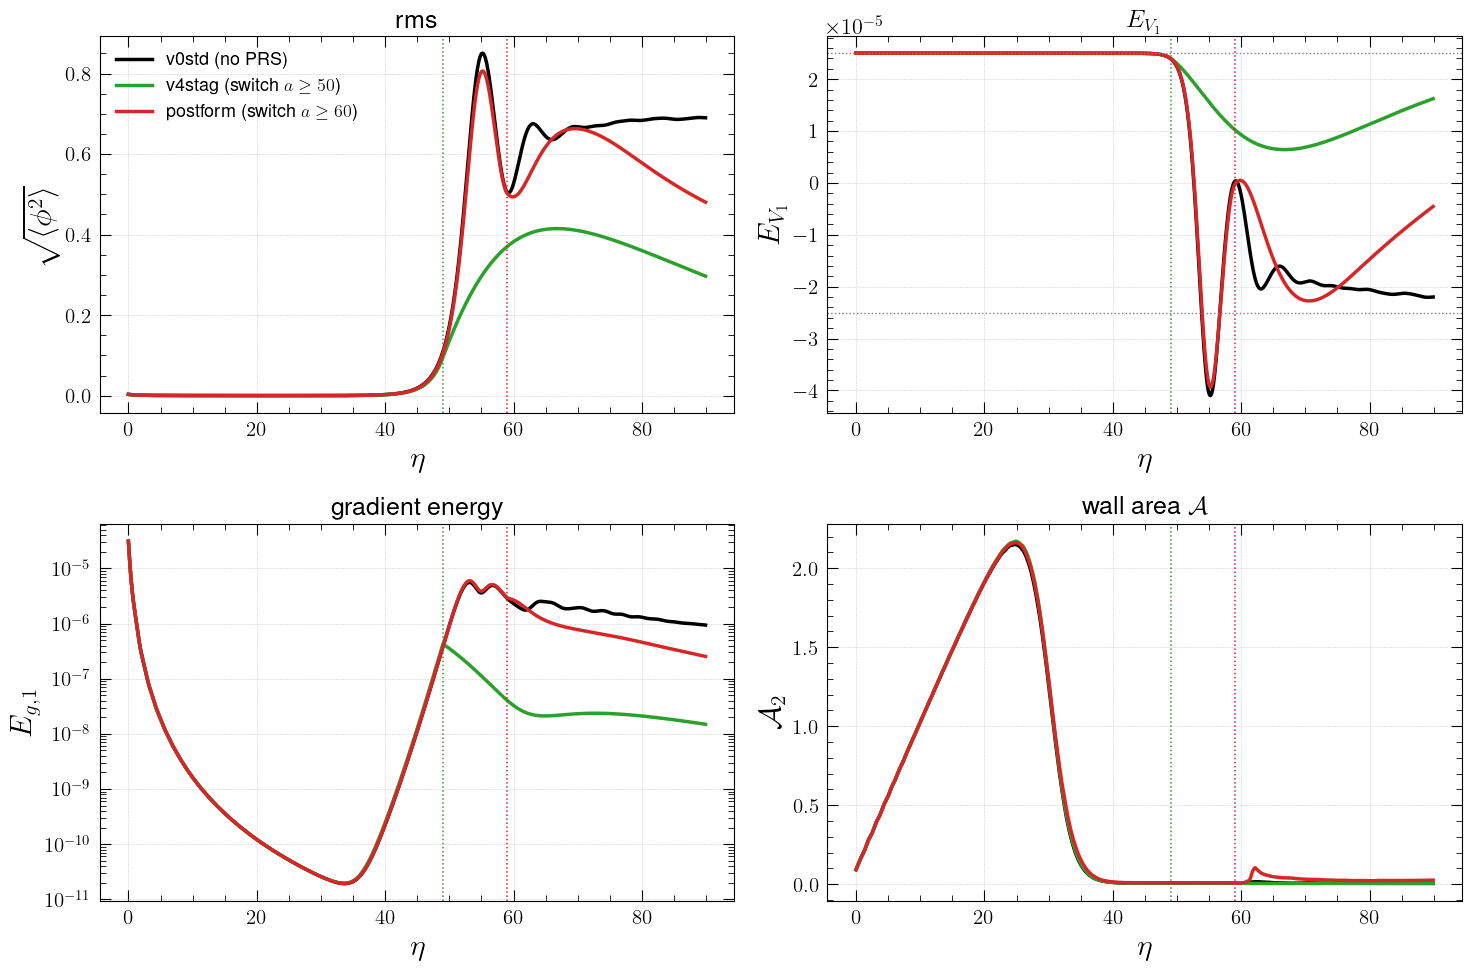

In [10]:
order = ["v0std", "v4stag", "staged60"]
ks = have(*order)
if not ks:
    print("waiting on:", [k for k in order if k not in ks])
else:
    col = {"v0std": "#000000", "v4stag": "#2ca02c", "staged60": "#d62728"}
    fig, ax = plt.subplots(2, 2, figsize=(15, 10))
    for k in order:
        if k not in ks: continue
        r = RUNS[k]; en = r["energies"]; sf = r["scale_factor"]; s0 = r["scalar_0"]; c = col[k]
        lab = {"v0std": "v0std (no PRS)", "v4stag": r"v4stag (switch $a\geq50$)",
               "staged60": r"postform (switch $a\geq60$)"}[k]
        ax[0,0].plot(s0["eta"], s0["rms_phi"], color=c, lw=2.5, label=lab)
        ax[0,1].plot(en["eta"], en["Ev_1"], color=c, lw=2.5)
        ax[1,0].plot(en["eta"], np.abs(en["Eg_1"])+1e-30, color=c, lw=2.5)
        eta, a, A = area(en, sf, "scal2"); ax[1,1].plot(eta, A, color=c, lw=2.5)
        if r["switch"]:
            # switch a -> eta on this run's own background
            hit = np.where(sf["a"] >= r["switch"])[0]
            if len(hit):
                for axx in ax.ravel(): axx.axvline(sf["eta"][hit[0]], color=c, ls=":", lw=1.1)
    ax[0,1].axhline(+V0, color="grey", ls=":", lw=1); ax[0,1].axhline(-V0, color="grey", ls=":", lw=1)
    paper_ax(ax[0,0], ylabel=r"$\sqrt{\langle\phi^2\rangle}$", title="rms")
    paper_ax(ax[0,1], ylabel=r"$E_{V_1}$", title=r"$E_{V_1}$")
    paper_ax(ax[1,0], ylabel=r"$E_{g,1}$", title="gradient energy"); ax[1,0].set_yscale("log")
    paper_ax(ax[1,1], ylabel=r"$\mathcal{A}_2$", title=r"wall area $\mathcal{A}$")
    ax[0,0].legend(fontsize=13, frameon=False)
    plt.tight_layout(); plt.savefig("Z4_prs_trials_staged.pdf", bbox_inches="tight"); plt.show()

## Resolution summary

`pts/wall = δ̄_min/(a·dx)` (δ̄_min=1.40, dx=0.70). For staged PRS to be meaningful the wall must
still be resolved at the switch `a`; PRS-from-t₀ holds it at the a=1 value (2.0).

In [11]:
print(f"{'key':10s} {'kind':8s} {'H0/mu':>5s} {'switch_a':>8s} {'a_break':>7s} "
      f"{'pts/wall@break':>14s} {'pts/wall@switch':>15s}")
for k, r in RUNS.items():
    if r["energies"] is None: continue
    eb, ib = break_point(r["energies"])
    ab = r["scale_factor"]["a"][ib] if ib is not None else None
    pwb = DELTA_MIN/(ab*r["dx"]) if ab else float("nan")
    sw = r["switch"]
    pws = DELTA_MIN/(max(sw,1)*r["dx"]) if sw else float("nan")
    print(f"{k:10s} {r['kind']:8s} {r['h0r']:5.1f} "
          f"{(str(sw) if sw else '--'):>8s} {(f'{ab:.1f}' if ab else '--'):>7s} "
          f"{pwb:14.4f} {pws:15.4f}")

key        kind     H0/mu switch_a a_break pts/wall@break pts/wall@switch
v0std      std        1.0       --    53.7         0.0372             nan
v3both     prs_t0     1.0       --      --            nan             nan
v4stag     staged     1.0       50      --            nan          0.0400
fric_mu01  friction   1.0       --    71.2         0.0281             nan
fric_mu1   friction   1.0       --    15.4         0.1299             nan
fric_g05   friction   1.0       --    63.0         0.0317             nan
fric_g2    friction   1.0       --    75.7         0.0264             nan
std_h05    std        0.5       --    38.0         0.0527             nan
std_h3     std        3.0       --    92.2         0.0217             nan
prst0_h05  prs_t0     0.5       --      --            nan             nan
prst0_h3   prs_t0     3.0       --      --            nan             nan
staged60   staged     1.0       60    53.7         0.0372          0.0333


### Notes
- μ test: overlap quantified in Q1; if non-zero, the rescaling argument is wrong — investigate.
- Q2 is the arbiter of the H0/μ-direction debate: read `a_break` straight off the table.
- 𝒜 here uses `scal2` (diagonal, the thinner/cleaner wall at β₄=0.1); `scal1` available too.
- These all use the φ=0 IC; the durable fix for a resolved network remains a vacuum-manifold IC.
- Saved PDFs: `Z4_prs_trials_{mu_test,H0mu_direction,prst0_drag,friction,staged}.pdf`.